# Нейронные сети

В этой работе пригодится библиотека PyTorch из лабораторной работы №1.

По нейронным сетям в интернете можно найти огромное количество информации и примеров (официальная документация фреймворка, Kaggle, даже ChatGPT, хотя последний стоит использовать с осторожностью) - вы можете использовать любые материалы в текущей работе, но будьте готовы ответить на вопросы по коду во время защиты.

Вспомогательные материалы:

[Курс по нейронным сетям](https://stepik.org/course/110281/syllabus)

[ШАД-овский курс по глубокому обучению](https://github.com/yandexdataschool/Practical_DL/tree/fall23)


В целом, содержательно данная работа дублирует часть курса по Глубокому обучению.


## Основы нейронных сетей (4 балла)

Кратко обсудим основные концепции, понимание которых необходимо для работы с PyTorch. В других фреймворках для нейронных сетей всё очень похоже.

1. **Датасеты**
  
  В PyTorch датасеты представлены классами `torch.utils.data.Dataset` или его наследниками. Они позволяют загружать данные и предоставляют доступ к ним для обучения и валидации.

2. **Нейронные сети**

  *Слои*

  Нейронные сети в PyTorch строятся с использованием `torch.nn.Module` (не единственный, но самый распространенный способ). Слои определяются внутри этих модулей и могут быть полносвязными (`torch.nn.Linear`), сверточными (`torch.nn.Conv2d`), рекуррентными (`torch.nn.LSTM`, `torch.nn.GRU`) и другими. Сло имеют входную и выходную размерность. В нейронной сети выходная размерность слоя должна быть равна входной размерности последующего слоя.

  *Функции активации*

  Функции активации, такие как ReLU (`torch.nn.ReLU`), Sigmoid (`torch.nn.Sigmoid`), Tanh (`torch.nn.Tanh`) и другие, применяются к выходу слоя для добавления нелинейности в сеть.

  *Лосс-функции*

  Лосс-функции измеряют расхождение между прогнозами модели и фактическими значениями. В зависимости от типа задачи могут использоваться различные функции активации, например, `torch.nn.CrossEntropyLoss` для классификации и `torch.nn.MSELoss` для регрессии.

  *Оптимизаторы*

  Оптимизаторы в PyTorch, такие как `torch.optim.SGD`, `torch.optim.Adam`, `torch.optim.Adagrad` и другие, используются для обновления параметров сети в процессе обучения с целью минимизации функции потерь.

  *Планировщики (шедулеры)*

  Планировщики позволяют динамически изменять скорость обучения в процессе обучения. Например, `torch.optim.lr_scheduler.ReduceLROnPlateau` уменьшает скорость обучения, если ошибка перестает уменьшаться, а `torch.optim.lr_scheduler.StepLR` или `torch.optim.lr_scheduler.CosineAnnealingLR` изменяют скорость обучения в заданные моменты или с периодическим расписанием.

3. **Обучение и валидация**

  Обучение модели включает в себя передачу данных через сеть, вычисление функции потерь, вычисление градиентов, обновление весов с использованием оптимизатора и повторение этого процесса на протяжении нескольких эпох. После обучения модели необходимо провести валидацию на независимом наборе данных для оценки ее производительности.

[Визуализация работы нейронных сетей](https://playground.tensorflow.org/).

Потренируемся писать полный цикл обучения нейронной сети на [следующем наборе данных](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data).

P.S. предлагаемая архитектура сети не является оптимальной, но позволяет научиться работать с основными строительными блоками PyTorch-а.

Прочитайте датасет (можно использовать библиотеку `opendatasets` для выгрузки данных с Kaggle). Посчитайте основные числовые характеристики для каждого столбца. Проанализируйте датасет на предмет дисбаланса классов. Сделайте вывод о необходимости каких-либо преобразований над данными.

Разбейте выборку на тренировочную и тестовую (`test_size=0.2, random_state=42`), проведите необходимые преобразования.

In [1]:
# устанавливаем зависимости
!pip -q install opendatasets kaggle
# импортируем библиотеки
import opendatasets as od

# задаем или обновляем dataset_url
dataset_url = "https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data"
# выполняем шаг вычисления
od.download(dataset_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: cr1pmoon
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data


100%|██████████| 48.6k/48.6k [00:00<00:00, 13.1MB/s]

In [2]:
# импортируем библиотеки
import pandas as pd

# задаем или обновляем df
df = pd.read_csv("/content/breast-cancer-wisconsin-data/data.csv")
#df.head()

# задаем или обновляем num_desc
num_desc = df.describe().T
# выводим результат
print(num_desc)
# задаем или обновляем summary
summary = pd.DataFrame({
    # выполняем шаг вычисления
    "dtype": df.dtypes,
    # выполняем шаг вычисления
    "n_missing": df.isna().sum(),
    # выполняем шаг вычисления
    "n_unique": df.nunique(),
# выполняем шаг вычисления
})

# добавим медиану для числовых
# начинаем цикл for
for col in df.columns:
    # проверяем условие
    if pd.api.types.is_numeric_dtype(df[col]):
        # задаем или обновляем summary.loc[col, "median"]
        summary.loc[col, "median"] = df[col].median()

# выводим результат
print(summary.sort_values(["n_missing", "n_unique"], ascending=False).head(15))



# задаем или обновляем target_col
target_col = "diagnosis"
# выполняем шаг вычисления
df[target_col].value_counts()
# задаем или обновляем df[target_col].value_counts(normalize
df[target_col].value_counts(normalize= True).rename(0)

                         count          mean           std          min  \
id                       569.0  3.037183e+07  1.250206e+08  8670.000000   
radius_mean              569.0  1.412729e+01  3.524049e+00     6.981000   
texture_mean             569.0  1.928965e+01  4.301036e+00     9.710000   
perimeter_mean           569.0  9.196903e+01  2.429898e+01    43.790000   
area_mean                569.0  6.548891e+02  3.519141e+02   143.500000   
smoothness_mean          569.0  9.636028e-02  1.406413e-02     0.052630   
compactness_mean         569.0  1.043410e-01  5.281276e-02     0.019380   
concavity_mean           569.0  8.879932e-02  7.971981e-02     0.000000   
concave points_mean      569.0  4.891915e-02  3.880284e-02     0.000000   
symmetry_mean            569.0  1.811619e-01  2.741428e-02     0.106000   
fractal_dimension_mean   569.0  6.279761e-02  7.060363e-03     0.049960   
radius_se                569.0  4.051721e-01  2.773127e-01     0.111500   
texture_se               

,0
diagnosis,
B,0.627417
M,0.372583


Почти во всех призанках пропусков нет

Столбец id можно удалить

Все признаки кроме diagnosis числовые. У разных призанков сильно разные масштаб. Поэтому желательно привести призкнаки к одному масштабу.

Также имеется дисбаланс классов, но это умеренный дисбаланс

In [3]:
# импортируем объекты из модуля
from sklearn.model_selection import train_test_split
# импортируем объекты из модуля
from sklearn.preprocessing import StandardScaler


# задаем или обновляем target_col
target_col = "diagnosis"
# задаем или обновляем drop_cols
drop_cols = [c for c in ["id", "Unnamed: 32"] if c in df.columns]
# задаем или обновляем df
df = df.drop(columns=drop_cols).copy()

# задаем или обновляем X
X = df.drop(columns=[target_col]).copy()
# задаем или обновляем y
y = df[target_col].map({"B": 0, "M": 1}).astype("int64")
# задаем или обновляем X_train, X_test, y_train, y_test
X_train, X_test, y_train, y_test = train_test_split(
    # выполняем шаг вычисления
    X, y,
    # задаем или обновляем test_size
    test_size=0.2,
    # задаем или обновляем random_state
    random_state=42,
    # задаем или обновляем stratify
    stratify=y
# выполняем шаг вычисления
)
# задаем или обновляем scaler
scaler = StandardScaler()
# задаем или обновляем X_train_scaled
X_train_scaled = scaler.fit_transform(X_train)
# задаем или обновляем X_test_scaled
X_test_scaled  = scaler.transform(X_test)

# задаем или обновляем X_train_scaled_df
X_train_scaled_df = pd.DataFrame(
    # выполняем шаг вычисления
    X_train_scaled,
    # задаем или обновляем columns
    columns=X_train.columns,
    # задаем или обновляем index
    index=X_train.index
# выполняем шаг вычисления
)
# задаем или обновляем X_test_scaled_df
X_test_scaled_df = pd.DataFrame(
    # выполняем шаг вычисления
    X_test_scaled,
    # задаем или обновляем columns
    columns=X_test.columns,
    # задаем или обновляем index
    index=X_test.index
# выполняем шаг вычисления
)

# задаем или обновляем train_df
train_df = X_train_scaled_df.copy()
# задаем или обновляем train_df["diagnosis"]
train_df["diagnosis"] = y_train

# задаем или обновляем test_df
test_df = X_test_scaled_df.copy()
# задаем или обновляем test_df["diagnosis"]
test_df["diagnosis"] = y_test


Создайте класс датасета. Типы данных, которые вам потребуются: `dtype=torch.float32`, `dtype=\torch.long`.

Инициализируйте даталоадеры (`batch_size=32`) для тренировочных и тестовых данных. Для теста данные перемешивать (параметр `shuffle`) не надо!

In [4]:
# импортируем библиотеки
import torch
# импортируем объекты из модуля
from torch.utils.data import Dataset, DataLoader

# определяем класс CustomDataset
class CustomDataset(Dataset):
    # определяем функцию __init__
    def __init__(self, dataframe):

      # задаем или обновляем df
      df = dataframe.copy()
      # задаем или обновляем self.target
      self.target = torch.tensor(df['diagnosis'].values, dtype= torch.long)

      # задаем или обновляем X
      X = df.drop(columns=["diagnosis"]).values

      # задаем или обновляем self.data
      self.data = torch.tensor(X, dtype= torch.float32)

    # определяем функцию __len__
    def __len__(self):
        # возвращаем результат
        return len(self.data)

    # определяем функцию __getitem__
    def __getitem__(self, idx):
        # возвращаем результат
        return self.data[idx], self.target[idx]




# задаем или обновляем train_dataset
train_dataset = CustomDataset(train_df)
# задаем или обновляем test_dataset
test_dataset = CustomDataset(test_df)

# задаем или обновляем train_loader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
# задаем или обновляем test_loader
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)



Создайте полносвязную нейронную сеть из нескольких слоёв. Между слоями используйте ReLU.

In [5]:
# импортируем библиотеки
import torch
# импортируем библиотеки
import torch.nn as nn

# определяем класс NeuralNetwork
class NeuralNetwork(nn.Module):
    # определяем функцию __init__
    def __init__(self, input_size):
        # выполняем шаг вычисления
        super(NeuralNetwork, self).__init__()
        # задаем или обновляем self.net
        self.net = nn.Sequential(
            # выполняем шаг вычисления
            nn.Linear(input_size, 64),
            # выполняем шаг вычисления
            nn.ReLU(),

            # выполняем шаг вычисления
            nn.Linear(64, 32),
            # выполняем шаг вычисления
            nn.ReLU(),

            # выполняем шаг вычисления
            nn.Linear(32,16),
            # выполняем шаг вычисления
            nn.ReLU(),

            # выполняем шаг вычисления
            nn.Linear(16,2)
        # выполняем шаг вычисления
        )

    # определяем функцию forward
    def forward(self, x):
        # возвращаем результат
        return self.net(x)

Следующий небольшой кусочек кода написан за вас. В нём используется кросс-энтропия в качестве функции потерь. Вспомните, какими характеристиками обладает данная функция и в чём особенность её реализации в PyTorch.

Письменно ответьте на вопрос, как сигмоидальная функция потерь соотносится с кросс-энтропийной.

In [6]:
# импортируем библиотеки
import torch.optim as optim
# импортируем объекты из модуля
from torch.optim import lr_scheduler

# задаем или обновляем device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# задаем или обновляем model
model = NeuralNetwork(input_size=train_df.shape[1] - 1).to(device)  # -1 за счет таргета
# задаем или обновляем criterion
criterion = nn.CrossEntropyLoss()
# задаем или обновляем optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)
# задаем или обновляем scheduler
scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

# задаем или обновляем num_epochs
num_epochs = 15
# задаем или обновляем train_losses
train_losses = []
# задаем или обновляем test_losses
test_losses = []
# задаем или обновляем train_accuracies
train_accuracies = []
# задаем или обновляем test_accuracies
test_accuracies = []

Ваш ответ: Сигмоидальная функция потерь - это бинарная кросс-энтропия, вероятность класса считается через sigmoid, и дальше считается кросс-энтропия для 2 классов

BCEWithLogitsLoss = sigmoid + binary cross-entropy
CrossEntropyLoss = softmax + multiclass cross-entropy

Напишите функции для тренировки и тестирования модели. Не забудьте про `optimizer.zero_grad()` при тренировке и `with torch.no_grad()` в тесте.

Также обратите внимание, что шаг планировщика нужно совершать после шага оптимизатора.

In [8]:
# импортируем библиотеки
import torch
# импортируем объекты из модуля
from tqdm import tqdm


# определяем функцию train
def train(model, train_loader, criterion, optimizer, scheduler, device):
    # выполняем шаг вычисления
    model.train()
    # задаем или обновляем running_loss
    running_loss = 0.0
    # задаем или обновляем correct_train
    correct_train = 0
    # задаем или обновляем total_train
    total_train = 0

    # начинаем цикл for
    for inputs, labels in tqdm(train_loader):
      # задаем или обновляем inputs
      inputs = inputs.to(device)
      # задаем или обновляем labels
      labels = labels.to(device)

      # задаем или обновляем optimizer.zero_grad(set_to_none
      optimizer.zero_grad(set_to_none=True)

      # задаем или обновляем outputs
      outputs = model(inputs)

      # задаем или обновляем loss
      loss = criterion(outputs, labels)

      # выполняем шаг вычисления
      loss.backward()

      # выполняем шаг вычисления
      optimizer.step()

      # задаем или обновляем preds
      preds = outputs.argmax(dim=1)
      # выполняем шаг вычисления
      correct_train += (preds == labels).sum().item()
      # задаем или обновляем total_train +
      total_train += labels.size(0)


      # задаем или обновляем running_loss +
      running_loss += loss.item() * labels.size(0)


        # Перемещение данных на устройство (GPU или CPU)
        # Обнуление градиентов параметров модели
        # Прямой проход: получение прогнозов от модели
        # Вычисление значения функции потерь
        # Обратное распространение: вычисление градиентов
        # Обновление параметров модели с помощью оптимизатора
        # Вычисление точности модели (Accuracy)
        # Аккумулирование потерь по батчам




    # задаем или обновляем train_loss
    train_loss = running_loss / total_train
    # задаем или обновляем train_accuracy
    train_accuracy = correct_train / total_train
    # Вычисление средней потери и точности на тренировочном наборе данных
    # Обновление шага расписания (scheduler)
    # проверяем условие
    if scheduler is not None:
      # выполняем шаг вычисления
      scheduler.step()

    # возвращаем результат
    return train_loss, train_accuracy


# определяем функцию test
def test(model, test_loader, criterion, device):
    # выполняем шаг вычисления
    model.eval()
    # задаем или обновляем running_loss
    running_loss = 0.0
    # задаем или обновляем correct_test
    correct_test = 0
    # задаем или обновляем total_test
    total_test = 0

    # выполняем шаг вычисления
    with torch.no_grad():
        # Проход по данным тестового загрузчика
        # начинаем цикл for
        for inputs, labels in tqdm(test_loader):
          # задаем или обновляем inputs
          inputs = inputs.to(device)
          # задаем или обновляем labels
          labels = labels.to(device)

          # задаем или обновляем outputs
          outputs = model(inputs)
          # задаем или обновляем loss
          loss = criterion(outputs, labels)

          # задаем или обновляем preds
          preds = outputs.argmax(dim=1)
          # выполняем шаг вычисления
          correct_test += (preds == labels).sum().item()
          # задаем или обновляем total_test +
          total_test += labels.size(0)


          # задаем или обновляем running_loss +
          running_loss += loss.item() * labels.size(0)


            # Перемещение данных на устройство (GPU или CPU)
            # Получение прогнозов от модели
            # Вычисление значения функции потерь
            # Вычисление точности модели (Accuracy)
            # Аккумулирование потерь по батчам



    # Вычисление средней потери и точности на тестовом наборе данных

    # задаем или обновляем test_loss
    test_loss = running_loss / total_test
    # задаем или обновляем test_accuracy
    test_accuracy = correct_test / total_test

    # возвращаем результат
    return test_loss, test_accuracy

Создайте цикл обучения вашей нейронной сети, используя написанные ранее функции.

Печатайте прогресс на каждой эпохе (`train_loss, train_accuracy, test_loss, test_accuracy`).

Постройте графики лосса и точности. Должно получиться что-то такое:

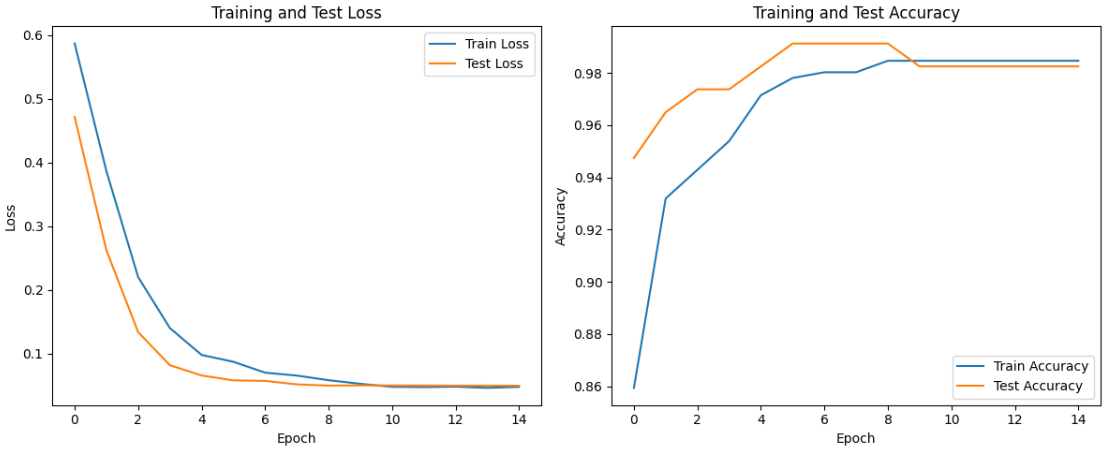

100%|██████████| 4/4 [00:00<00:00, 882.55it/s]


Epoch [01/15] | train_loss=0.6324, train_acc=0.6747 | test_loss=0.5760, test_acc=0.8158


100%|██████████| 4/4 [00:00<00:00, 913.64it/s]


Epoch [02/15] | train_loss=0.5100, train_acc=0.9121 | test_loss=0.4299, test_acc=0.9386


100%|██████████| 4/4 [00:00<00:00, 1060.91it/s]


...

Epoch [13/15] | train_loss=0.0464, train_acc=0.9868 | test_loss=0.0619, test_acc=0.9912


100%|██████████| 4/4 [00:00<00:00, 769.99it/s]


Epoch [14/15] | train_loss=0.0456, train_acc=0.9890 | test_loss=0.0619, test_acc=0.9912


100%|██████████| 4/4 [00:00<00:00, 728.97it/s]


Epoch [15/15] | train_loss=0.0450, train_acc=0.9890 | test_loss=0.0621, test_acc=0.9912


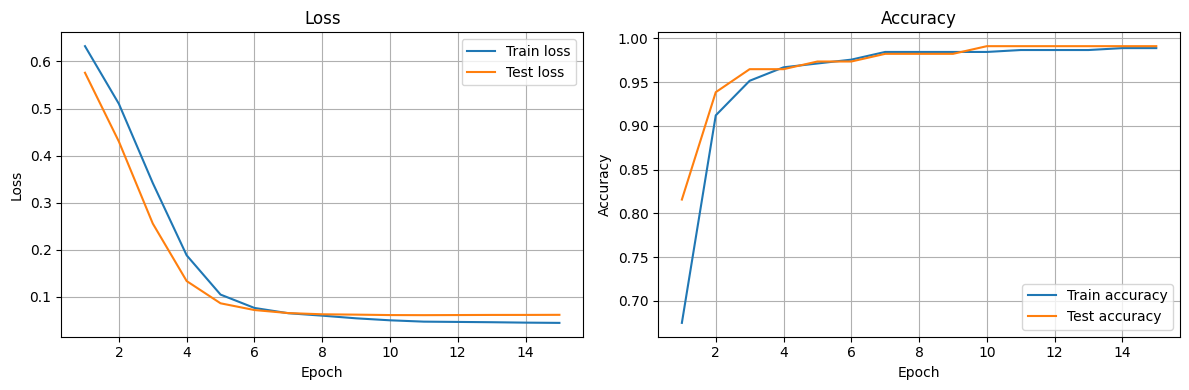

In [9]:
# импортируем библиотеки
import matplotlib.pyplot as plt


# задаем или обновляем num_epochs
num_epochs = 15


# задаем или обновляем train_losses, test_losses
train_losses, test_losses = [], []
# задаем или обновляем train_accuracies, test_accuracies
train_accuracies, test_accuracies = [], []


# начинаем цикл for
for epoch in range(num_epochs):
  # задаем или обновляем train_loss, train_acc
  train_loss, train_acc = train(model, train_loader, criterion, optimizer, scheduler, device)
  # задаем или обновляем test_loss, test_acc
  test_loss, test_acc = test(model, test_loader, criterion, device)

  # выполняем шаг вычисления
  train_losses.append(train_loss)
  # выполняем шаг вычисления
  test_losses.append(test_loss)
  # выполняем шаг вычисления
  train_accuracies.append(train_acc)
  # выполняем шаг вычисления
  test_accuracies.append(test_acc)

  # выводим результат
  print(
        # выполняем шаг вычисления
        f"Epoch [{epoch+1:02d}/{num_epochs}] | "
        # задаем или обновляем f"train_loss
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
        # задаем или обновляем f"test_loss
        f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")


# torch.save(model.state_dict(), 'model_checkpoint.pth') - можно сохранить модель по итогу обучения

# задаем или обновляем epochs
epochs = range(1, num_epochs + 1)

# строим или настраиваем график
plt.figure(figsize=(12, 4))

# строим или настраиваем график
plt.subplot(1, 2, 1)
# строим или настраиваем график
plt.plot(epochs, train_losses, label="Train loss")
# строим или настраиваем график
plt.plot(epochs, test_losses, label="Test loss")
# строим или настраиваем график
plt.xlabel("Epoch")
# строим или настраиваем график
plt.ylabel("Loss")
# строим или настраиваем график
plt.title("Loss")
# строим или настраиваем график
plt.grid(True)
# строим или настраиваем график
plt.legend()

# строим или настраиваем график
plt.subplot(1, 2, 2)
# строим или настраиваем график
plt.plot(epochs, train_accuracies, label="Train accuracy")
# строим или настраиваем график
plt.plot(epochs, test_accuracies, label="Test accuracy")
# строим или настраиваем график
plt.xlabel("Epoch")
# строим или настраиваем график
plt.ylabel("Accuracy")
# строим или настраиваем график
plt.title("Accuracy")
# строим или настраиваем график
plt.grid(True)
# строим или настраиваем график
plt.legend()

# строим или настраиваем график
plt.tight_layout()
# строим или настраиваем график
plt.show()

## Специальные архитектуры нейронных сетей

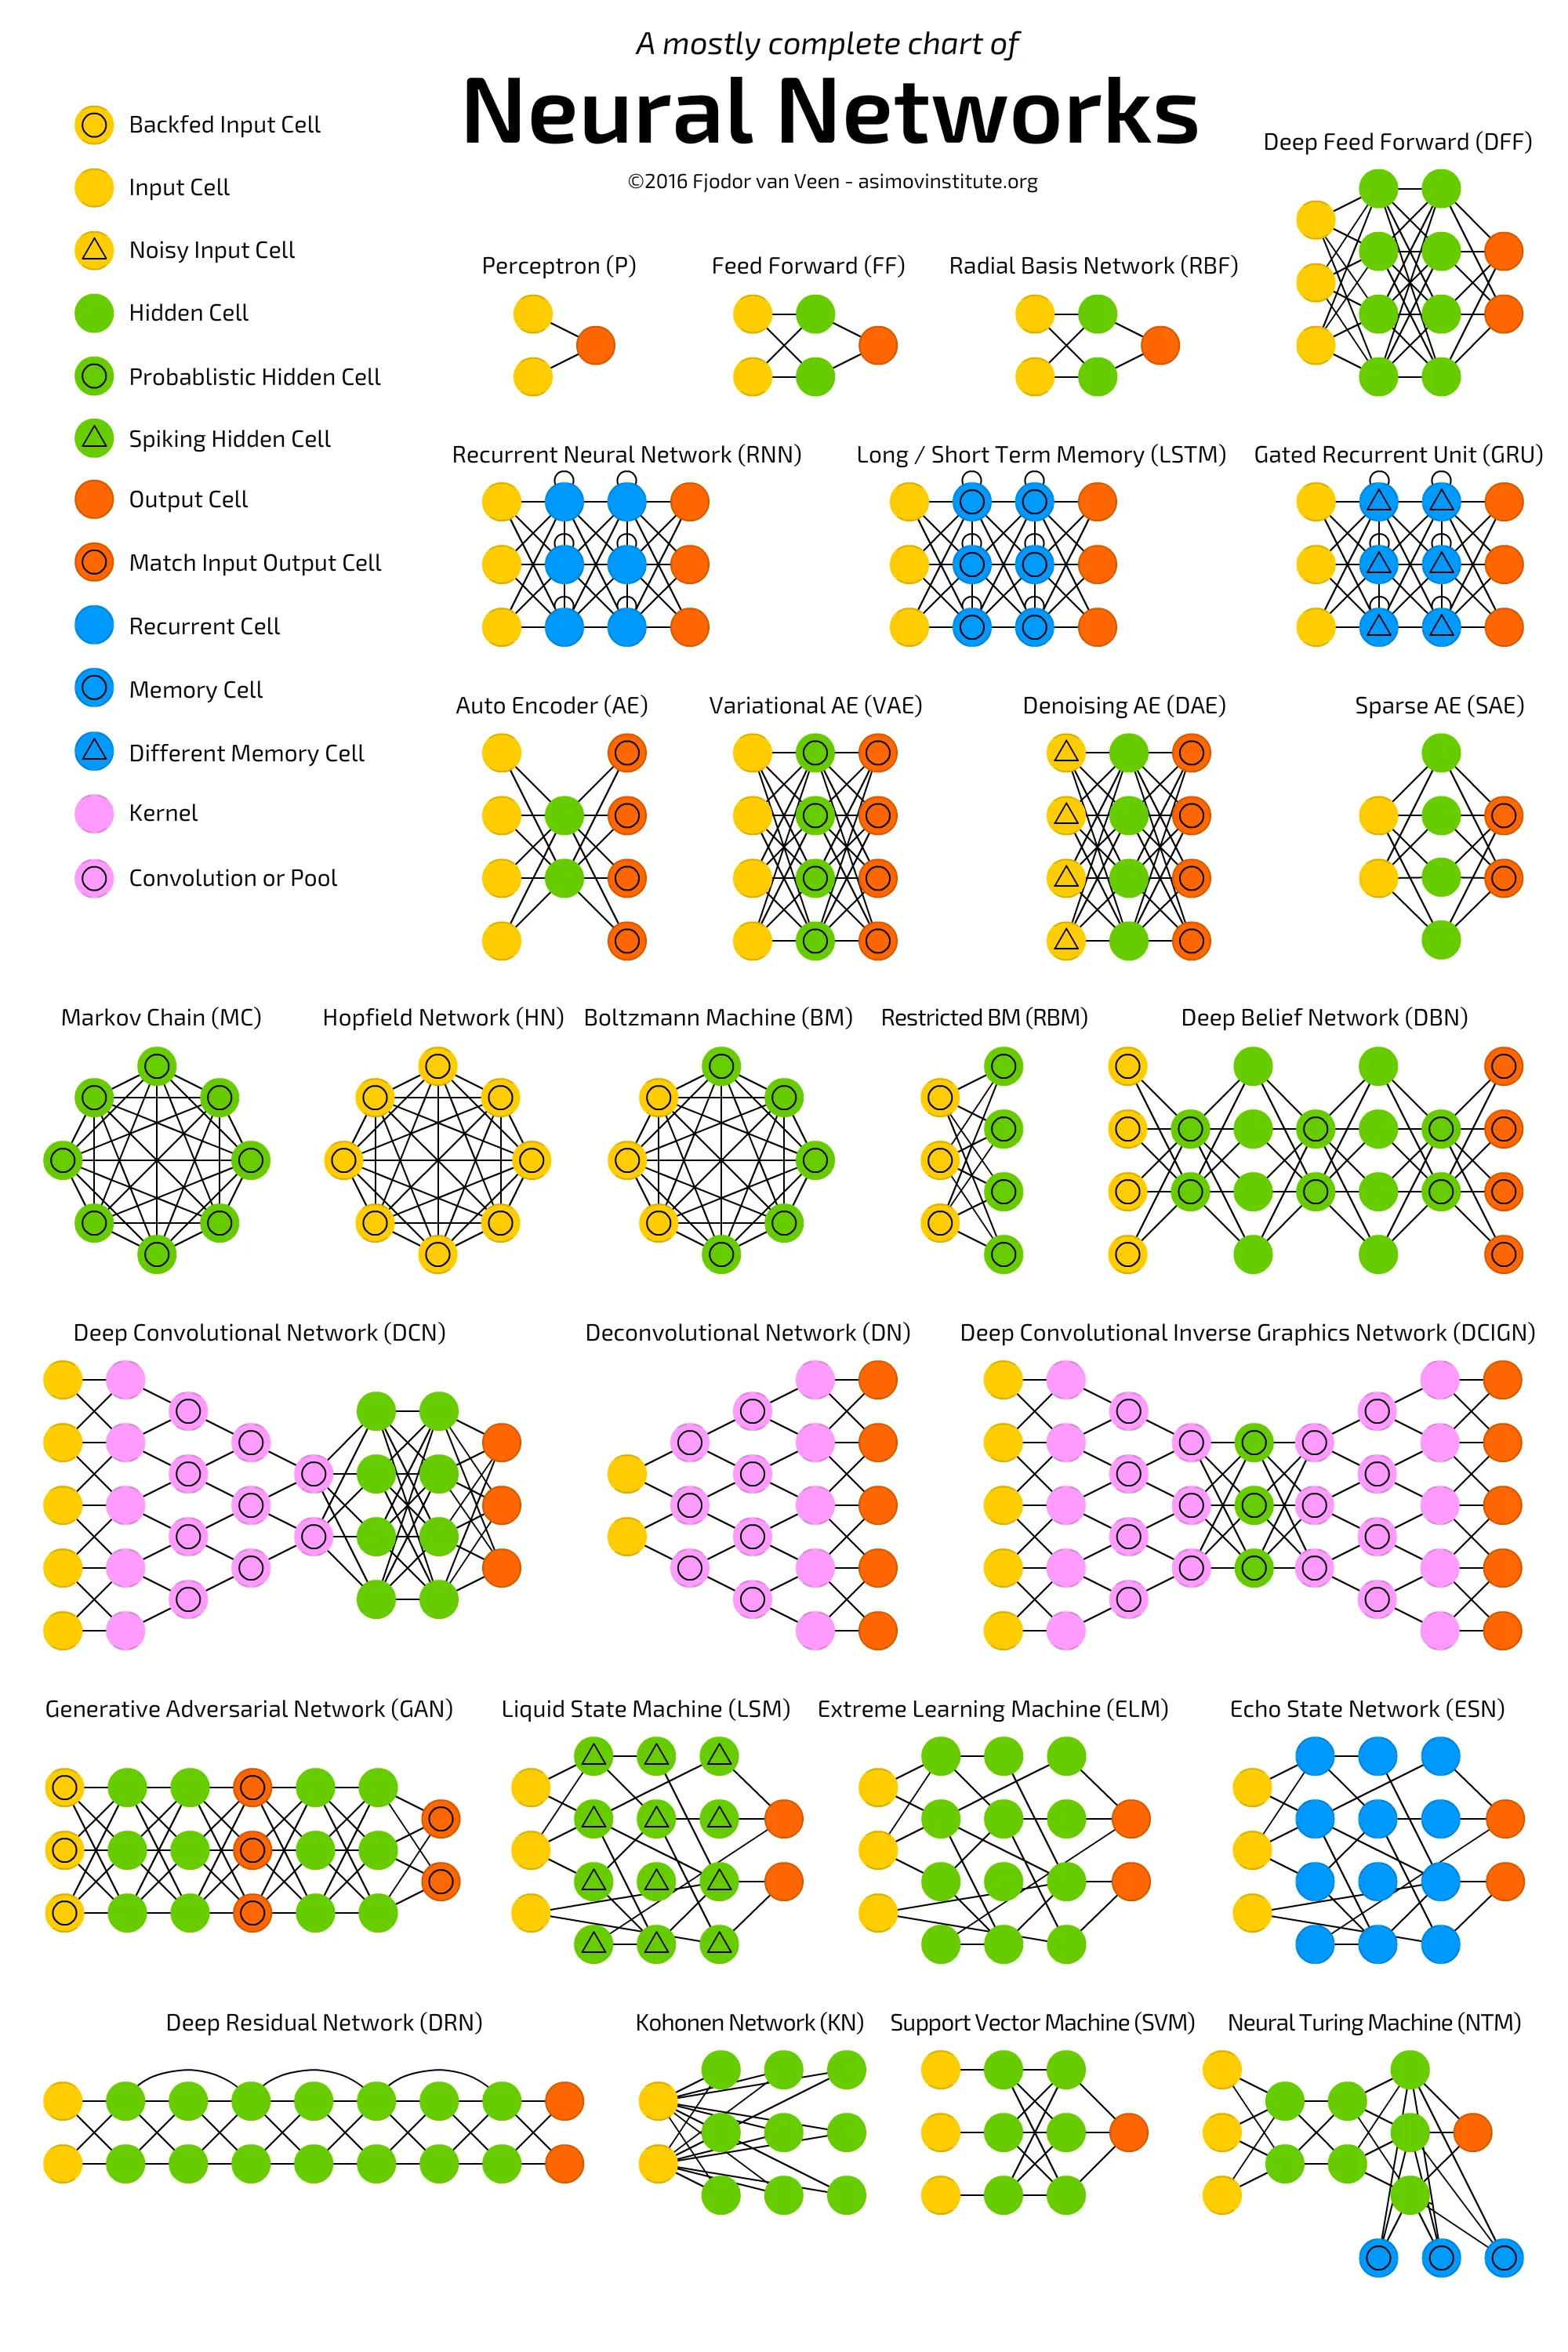

[Источник картинки](https://towardsdatascience.com/the-mostly-complete-chart-of-neural-networks-explained-3fb6f2367464)

В последующих заданиях можно использовать предоставленные датасеты ЛИБО найти какой-либо свой, обладающий схожими характеристиками.

### CNN (4 балла)

Свёрточные нейронные сети работают по принципу "возьмем фильтры с настраиваемыми весами и будем изменять эти веса так, чтобы фильтры выделяли те признаки, которые помогут нам решить задачу". Обычно свёрточные нейронные сети состоят из блоков свёртки и пулинга (уменьшение размерности), поверх которых добавляются несколько полносвязных линейных слоёв. [Визуализация работы свёрточной нейронной сети](https://poloclub.github.io/cnn-explainer/)

Будем решать задачу многоклассовой классификации. Датасет возьмем [отсюда](https://www.kaggle.com/datasets/puneet6060/intel-image-classification/data). Он содержит картинки с различными пейзажами. Присутсвуют такие классы, как 'buildings', 'forest', 'glacier', 'mountain', 'sea', 'street'.

Скачайте датасет (можно использвоать библиотеку `opendatasets`)

In [10]:
# импортируем библиотеки
import opendatasets as od

# задаем или обновляем dataset_url
dataset_url = "https://www.kaggle.com/datasets/puneet6060/intel-image-classification"
# выполняем шаг вычисления
od.download(dataset_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: cr1pmoon
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification


100%|██████████| 346M/346M [00:02<00:00, 160MB/s]


Создайте даталоадеры для тренировочных и тестовых данных. Используйте `torchvision.datasets.ImageFolder`. Одним из параметров данной функции является `transform`. Попробуйте применить к вашим данным какие-либо [трансформации](https://pytorch.org/vision/stable/transforms.html).

In [11]:
# импортируем объекты из модуля
from torchvision import datasets, transforms
# импортируем объекты из модуля
from torch.utils.data import DataLoader

# задаем или обновляем train_path
train_path = "intel-image-classification/seg_train/seg_train"
# задаем или обновляем test_path
test_path = "intel-image-classification/seg_test/seg_test"
# задаем или обновляем batch_size
batch_size = 256

# задаем или обновляем transformer
transformer = transforms.Compose([
    # выполняем шаг вычисления
    transforms.Resize((224, 224)),
    # задаем или обновляем transforms.RandomHorizontalFlip(p
    transforms.RandomHorizontalFlip(p=0.5),
    # выполняем шаг вычисления
    transforms.RandomRotation(10),
    # выполняем шаг вычисления
    transforms.ToTensor(),
    # задаем или обновляем transforms.Normalize(mean
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         # задаем или обновляем std
                         std=(0.229, 0.224, 0.225)),
# выполняем шаг вычисления
])


# задаем или обновляем train_dataset
train_dataset = datasets.ImageFolder(root= train_path, transform= transformer)
# задаем или обновляем test_dataset
test_dataset = datasets.ImageFolder(root= test_path, transform= transformer)

# задаем или обновляем train_loader
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory= True)
# задаем или обновляем test_loader
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory= True)

Выведем пару картинок, обратившись к содержимому даталоадеров.

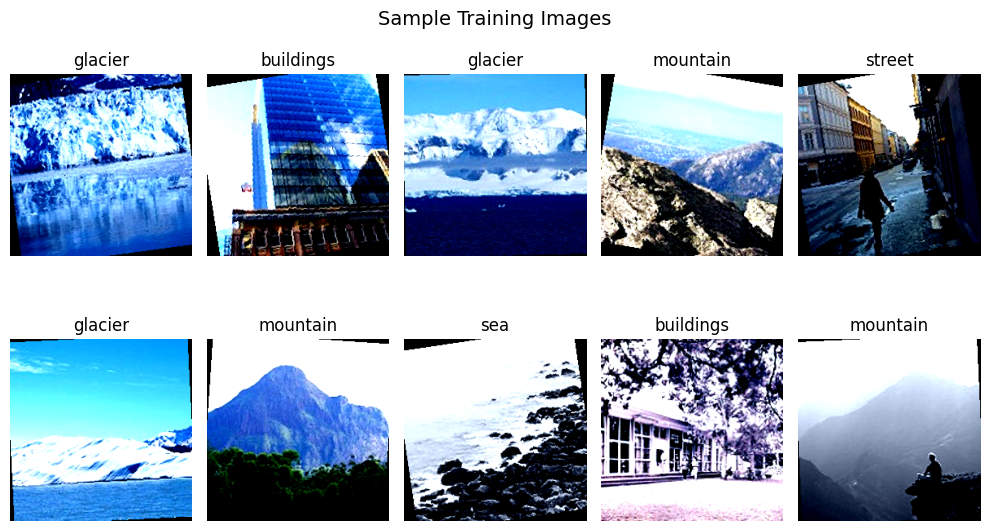

In [12]:
# импортируем библиотеки
import numpy as np


# задаем или обновляем images, labels
images, labels = next(iter(train_loader))
# задаем или обновляем class_names
class_names = train_loader.dataset.classes

# задаем или обновляем fig, ax
fig, ax = plt.subplots(nrows=2, ncols=5, figsize=(10, 6))
# задаем или обновляем idx
idx = 0

# начинаем цикл for
for i in range(2):
    # начинаем цикл for
    for j in range(5):
        # задаем или обновляем label
        label = class_names[labels[idx].item()]
        # выполняем шаг вычисления
        ax[i, j].set_title(f"{label}")
        # задаем или обновляем img
        img = images[idx]

        # задаем или обновляем img
        img = img / 2 + 0.5  # обратное преобразование из-за трансформаций. возможно, вам оно не пригодится

        # задаем или обновляем npimg
        npimg = np.transpose(img.numpy(), (1, 2, 0))
        # выполняем шаг вычисления
        ax[i, j].imshow(npimg)
        # выполняем шаг вычисления
        ax[i, j].axis("off")
        # задаем или обновляем idx +
        idx += 1

# строим или настраиваем график
plt.tight_layout()
# строим или настраиваем график
plt.suptitle("Sample Training Images", fontsize=14)
# строим или настраиваем график
plt.show()

Реализуйте свёрточную нейронную сеть и обучите её, используя тот же пайплайн, что и в предыдущем задании.

Задача не из простых, так как при использовании свёрточных нейронных сетей нужно внимательно следить за размерностями входных и выходных слоёв. Вам пригодятся такие слои, как Conv2d, BatchNorm2d, MaxPool2d, Linear или любые другие на ваше усмотрение. В качестве функции активации можно использовать ReLU.

Задача достаточно творческая, сфокусируйтесь на проведении экспериментов, а не на том, чтобы "выбить метрику". В данной задаче accuracy выше 0.7 на тесте будем считать хорошим результатом.

In [13]:
# импортируем библиотеки
import torch
# импортируем библиотеки
import torch.nn as nn
# импортируем библиотеки
import torch, gc
# выполняем шаг вычисления
gc.collect()
# используем функции PyTorch
torch.cuda.empty_cache()

# определяем класс ConvNet
class ConvNet(nn.Module):
    # определяем функцию __init__
    def __init__(self, num_classes=6):
        # выполняем шаг вычисления
        super(ConvNet, self).__init__()


        # задаем или обновляем self.features
        self.features = nn.Sequential(
            # задаем или обновляем nn.Conv2d(3, 32, kernel_size
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            # выполняем шаг вычисления
            nn.BatchNorm2d(32),
            # задаем или обновляем nn.ReLU(inplace
            nn.ReLU(inplace=True),
            # выполняем шаг вычисления
            nn.MaxPool2d(2),

            # задаем или обновляем nn.Conv2d(32, 64, kernel_size
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            # выполняем шаг вычисления
            nn.BatchNorm2d(64),
            # задаем или обновляем nn.ReLU(inplace
            nn.ReLU(inplace=True),
            # выполняем шаг вычисления
            nn.MaxPool2d(2),

            # задаем или обновляем nn.Conv2d(64, 128, kernel_size
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            # выполняем шаг вычисления
            nn.BatchNorm2d(128),
            # задаем или обновляем nn.ReLU(inplace
            nn.ReLU(inplace=True),
            # выполняем шаг вычисления
            nn.MaxPool2d(2),

            # задаем или обновляем nn.Conv2d(128, 256, kernel_size
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            # выполняем шаг вычисления
            nn.BatchNorm2d(256),
            # задаем или обновляем nn.ReLU(inplace
            nn.ReLU(inplace=True),
            # выполняем шаг вычисления
            nn.MaxPool2d(2),



        # выполняем шаг вычисления
        )



        # задаем или обновляем self.Classifier
        self.Classifier = nn.Sequential(
            # выполняем шаг вычисления
            nn.Flatten(),
            # выполняем шаг вычисления
            nn.Linear(256*14*14, 256),
            # задаем или обновляем nn.ReLU(inplace
            nn.ReLU(inplace=True),
            # выполняем шаг вычисления
            nn.Dropout(0.3),
            # выполняем шаг вычисления
            nn.Linear(256, num_classes)
        # выполняем шаг вычисления
        )

    # определяем функцию forward
    def forward(self, input):
        # задаем или обновляем x
        x = self.features(input)
        # задаем или обновляем x
        x = self.Classifier(x)

        # возвращаем результат
        return x

In [14]:
# импортируем библиотеки
import torch.optim as optim
# импортируем объекты из модуля
from torch.optim import lr_scheduler



# задаем или обновляем device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# задаем или обновляем model
model = ConvNet(num_classes= 6).to(device)

# задаем или обновляем criterion
criterion = nn.CrossEntropyLoss()
# задаем или обновляем optimizer
optimizer = optim.Adam(model.parameters(), lr= 1e-3)
# задаем или обновляем scheduler
scheduler = lr_scheduler.StepLR(optimizer, step_size=5, gamma= 0.5)

# задаем или обновляем num_epochs
num_epochs = 5
# задаем или обновляем train_losses, test_losses
train_losses, test_losses = [], []
# задаем или обновляем train_accuracies, test_accuracies
train_accuracies, test_accuracies = [], []
# задаем или обновляем w0
w0 = model.features[0].weight.detach().clone()

# задаем или обновляем train_loss, train_acc
train_loss, train_acc = train(model, train_loader, criterion, optimizer, scheduler, device)




# начинаем цикл for
for epoch in range(num_epochs):
  # задаем или обновляем train_loss, train_acc
  train_loss, train_acc = train(model, train_loader, criterion, optimizer, scheduler, device)
  # задаем или обновляем test_loss, test_acc
  test_loss, test_acc = test(model, test_loader, criterion, device)
  # выполняем шаг вычисления
  train_losses.append(train_loss)
  # выполняем шаг вычисления
  test_losses.append(test_loss)
  # выполняем шаг вычисления
  train_accuracies.append(train_acc)
  # выполняем шаг вычисления
  test_accuracies.append(test_acc)


  # выводим результат
  print(
     # выполняем шаг вычисления
     f"Epoch [{epoch+1:02d}/{num_epochs}] | "
     # задаем или обновляем f"train_loss
     f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
     # задаем или обновляем f"test_loss
     f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}"
  # выполняем шаг вычисления
  )


100%|██████████| 12/12 [00:08<00:00,  1.41it/s]


Epoch [01/5] | train_loss=0.9981, train_acc=0.6122 | test_loss=0.8532, test_acc=0.6780


100%|██████████| 12/12 [00:17<00:00,  1.48s/it]


Epoch [02/5] | train_loss=0.8885, train_acc=0.6596 | test_loss=0.7774, test_acc=0.7153


100%|██████████| 12/12 [00:07<00:00,  1.50it/s]


Epoch [03/5] | train_loss=0.7869, train_acc=0.7041 | test_loss=0.8363, test_acc=0.6863


100%|██████████| 12/12 [00:08<00:00,  1.33it/s]


Epoch [04/5] | train_loss=0.7405, train_acc=0.7330 | test_loss=0.6892, test_acc=0.7627


100%|██████████| 12/12 [00:16<00:00,  1.38s/it]

Epoch [05/5] | train_loss=0.6308, train_acc=0.7699 | test_loss=0.5548, test_acc=0.8047


Посмотрим, что наша модель предсказывает, на отложенной выборке. Так как для новых данных у нас отсутсвует разметка по классам, придется создать кастомный датасет для подгружения данных по частям. Подгрзить все картинки сразу нельзя - они не поместятся в оперативную память.

Создайте кастомный датасет для того, чтобы картинки подгружались динамически. [Пример можно найти здесь](https://www.learnpytorch.io/04_pytorch_custom_datasets/). Не забудьте применить трансормации, если вы использовали их при обучении модели.

Выведите пример того, что предсказывает ваша модель.

{'buildings': 2191, 'forest': 2271, 'glacier': 2404, 'mountain': 2512, 'sea': 2274, 'street': 2382}
predicted indices: [5, 3, 5, 3, 3, 1, 4, 2, 4, 5]
unique predicted: [1, 2, 3, 4, 5]


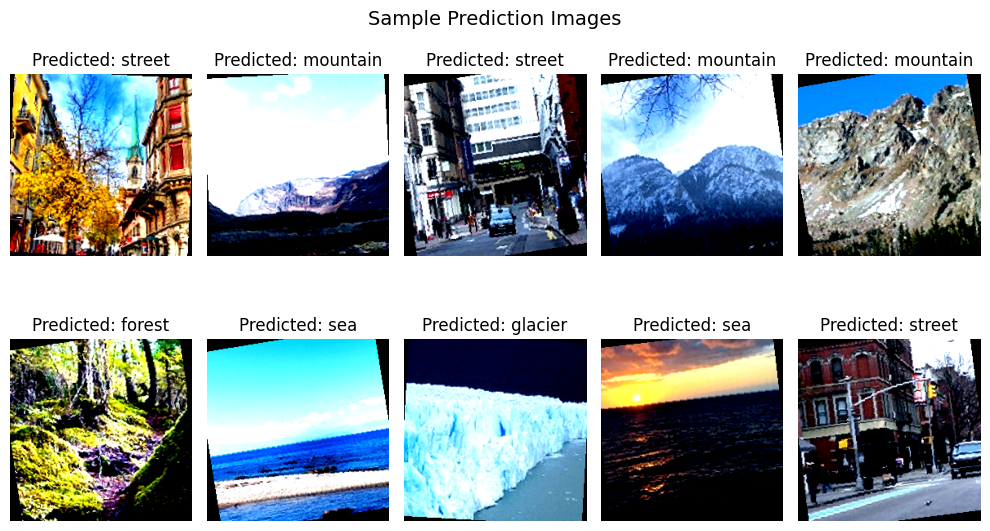

In [15]:
# импортируем библиотеки
import os
# импортируем объекты из модуля
from PIL import Image
# импортируем библиотеки
import torch
# импортируем объекты из модуля
from torch.utils.data import Dataset, DataLoader
# импортируем объекты из модуля
from collections import Counter

# определяем класс CustomDataset
class CustomDataset(torch.utils.data.Dataset):
    # определяем функцию __init__
    def __init__(self, root_dir, transform=None):
        # задаем или обновляем self.root_dir
        self.root_dir = root_dir
        # задаем или обновляем self.transform
        self.transform = transform

        # задаем или обновляем exts
        exts = (".jpg", ".jpeg", ".png", ".bmp")
        # задаем или обновляем self.images
        self.images = []
        # начинаем цикл for
        for root, _, files in os.walk(root_dir):
          # начинаем цикл for
          for f in files:
            # проверяем условие
            if f.lower().endswith(exts):
              # выполняем шаг вычисления
              self.images.append(os.path.join(root, f))
        # выполняем шаг вычисления
        self.images.sort()

    # определяем функцию __len__
    def __len__(self):
        # возвращаем результат
        return len(self.images)

    # определяем функцию __getitem__
    def __getitem__(self, idx):
        # задаем или обновляем img_path
        img_path = self.images[idx]
        # задаем или обновляем image
        image = Image.open(img_path).convert("RGB")

        # проверяем условие
        if self.transform is not None:
          # задаем или обновляем image
          image = self.transform(image)

        # возвращаем результат
        return image

# задаем или обновляем class_names
class_names = train_dataset.classes

# задаем или обновляем pred_path
pred_path = "intel-image-classification/seg_pred/seg_pred"
# задаем или обновляем pred_data
pred_data = CustomDataset(pred_path, transform=transformer)

# задаем или обновляем batch_size
batch_size = 10
# задаем или обновляем pred_loader
pred_loader = DataLoader(pred_data, batch_size=batch_size, shuffle=False)

# выполняем шаг вычисления
model.eval()

# задаем или обновляем images
images = next(iter(pred_loader)).to(device)

# выполняем шаг вычисления
with torch.no_grad():
    # задаем или обновляем outputs
    outputs = model(images)
    # задаем или обновляем _, predicted
    _, predicted = torch.max(outputs, 1)


# задаем или обновляем counts
counts = Counter(train_dataset.targets)

# выводим результат
print({train_dataset.classes[k]: v for k, v in counts.items()})

# выводим результат
print("predicted indices:", predicted.cpu().tolist())
# выводим результат
print("unique predicted:", torch.unique(predicted).cpu().tolist())

# задаем или обновляем fig, ax
fig, ax = plt.subplots(nrows=2, ncols=5, figsize=(10, 6))
# задаем или обновляем idx
idx = 0



# начинаем цикл for
for i in range(2):
    # начинаем цикл for
    for j in range(5):
        # задаем или обновляем label
        label = class_names[predicted[idx].item()]
        # выполняем шаг вычисления
        ax[i, j].set_title(f"Predicted: {label}")
        # задаем или обновляем img
        img = images[idx].cpu() / 2 + 0.5  # обратное преобразование из-за трансформаций. возможно, вам оно не пригодится
        # задаем или обновляем npimg
        npimg = np.transpose(img.numpy(), (1, 2, 0))
        # выполняем шаг вычисления
        ax[i, j].imshow(npimg)
        # выполняем шаг вычисления
        ax[i, j].axis("off")
        # задаем или обновляем idx +
        idx += 1

# строим или настраиваем график
plt.tight_layout()
# строим или настраиваем график
plt.suptitle("Sample Prediction Images", fontsize=14)
# строим или настраиваем график
plt.show()

### RNN (6 баллов)

Recurrent Neural Network или рекуррентная нейронная сеть. Её логическим продолжением стала архитектура LSTM (Long Short-term Memory). Эти архитектуры призваны решать задачу обработки последовательностей и учитывают не только сигналы с непосредственно предыдщуего слоя, но и сигналы с более дальних слоёв.

[Здесь](https://qudata.com/ml/ru/NN_RNN_Torch.html) можно найти хорошее объяснение.

Будем решать задачу генерации текста. Принцип работы следующий: модель имеет представление обо всех словах словаря. На вход модель получает последовательность слов, её задача - определить, какое слово из словаря будет наиболее вероятным продолжением этой последовательности. То есть, по сути решается задача многоклассовой классификации.

В данном случае под "словом" понимает токен - то есть любая единица текстовых данных, которой присвоен код, - будь то буква, слог, слово или несколько слов сразу.

В качестве данных возьмем любую из книг "Игра престолов". Тексты книг можно найти [здесь](https://www.kaggle.com/datasets/khulasasndh/game-of-thrones-books).

Начнем с небольшой предобработки. Напишите функцию предобработки, которая приведет текст к нижнему регистру, удалит из него конструкции вида "Page n". Также удалим все символы, которые не являются буквами, пробелами, точками или вопросительными знаками. В том числе удалим переносы строк.

In [34]:
# импортируем библиотеки
import re

# определяем функцию preprocess_text
def preprocess_text(text):

  # задаем или обновляем text
  text = text.lower()

  # задаем или обновляем text
  text = re.sub(r"\bpage\s*\d+\d", " ", text, flags= re.IGNORECASE)

  # задаем или обновляем text
  text = re.sub(r"[\r\n\t]+", " ", text)

  # задаем или обновляем out
  out = []
  # начинаем цикл for
  for ch in text:
    # проверяем условие
    if ch.isalpha() or ch in (" ", ".", "?"):
      # выполняем шаг вычисления
      out.append(ch)
    # ветка иначе
    else:
      # выполняем шаг вычисления
      out.append(" ")

  # задаем или обновляем text
  text = "".join(out)


  # задаем или обновляем text
  text = re.sub(r"\s+", " ", text).strip()

  # возвращаем результат
  return text

Теперь нам потребуется токенизатор, который будет присваивать словам числовые коды. В качестве метода разбиения текста на составные части предлагается использовать`sent_tokenize` и `word_tokenize` из `nltk`.

In [40]:
# импортируем объекты из модуля
from nltk.tokenize import sent_tokenize, word_tokenize
# импортируем библиотеки
import nltk

# выполняем шаг вычисления
nltk.download("punkt")
# выполняем шаг вычисления
nltk.download("punkt_tab")

# определяем класс Tokenizer
class Tokenizer:
    # определяем функцию __init__
    def __init__(self):
        # задаем или обновляем self.unknown_token
        self.unknown_token = 'UNK'
        # задаем или обновляем self.unknown_index
        self.unknown_index = 0
        # задаем или обновляем self.word2ind
        self.word2ind = {self.unknown_token: self.unknown_index}
        # задаем или обновляем self.ind2word
        self.ind2word = {self.unknown_index: self.unknown_token}

    # определяем функцию fit
    def fit(self, corpus):

        # задаем или обновляем vocab
        vocab = set()

        # начинаем цикл for
        for s in corpus:
          # начинаем цикл for
          for w in word_tokenize(s):
            # выполняем шаг вычисления
            vocab.add(w)

        # задаем или обновляем vocab
        vocab = sorted(vocab)




        # начинаем цикл for
        for i,w in enumerate(sorted(vocab), start=1):
          # задаем или обновляем self.word2ind[w]
          self.word2ind[w] = i
          # задаем или обновляем self.ind2word[i]
          self.ind2word[i] = w
        # возвращаем результат
        return self



    # определяем функцию text2ind
    def text2ind(self, text):
        # задаем или обновляем words
        words = word_tokenize(text)
        # задаем или обновляем sequence
        sequence = [self.word2ind.get(word, self.unknown_index) for word in words]
        # возвращаем результат
        return sequence

    # определяем функцию ind2text
    def ind2text(self, sequence):
        # задаем или обновляем words
        words = [self.ind2word.get(index, self.unknown_token) for index in sequence]
        # возвращаем результат
        return words

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Подготовим датасет. Для обучения модели было бы неплохо привести все подаваемые на вход сети последовательности к одной длине. Можно работать и с последовательностями разной длины, если объединять их в батчи, где длины совпадают, но сейчас мы будем придерживаться более простой тактики.

Реализуйте функцию `split_sentences_into_chunks`, которая будет возвращать последовательности длиной `max_seq_length + 1` (единица, так как в дальнейшем крайнее правое слово станет таргетом). Будем добавлять паддинг слева, если длина текста не делится на `max_seq_length + 1` нацело. В качестве значения для паддинга можете использовать `tokenizer.unknown_index`.

In [31]:
# определяем функцию split_sentences_into_chunks
def split_sentences_into_chunks(sentences, tokenizer, max_seq_length=8):

  # задаем или обновляем chunk_len
  chunk_len = max_seq_length + 1
  # задаем или обновляем pad
  pad = tokenizer.unknown_index

  # задаем или обновляем all_ids
  all_ids = []
  # начинаем цикл for
  for s in sentences:
    # выполняем шаг вычисления
    all_ids.extend(tokenizer.text2ind(s))

  # задаем или обновляем r
  r = len(all_ids) % chunk_len

  # проверяем условие
  if r != 0:
    # задаем или обновляем need
    need = chunk_len - r
    # задаем или обновляем all_ids
    all_ids = [pad] * need + all_ids

  # задаем или обновляем chunks
  chunks = [all_ids[i:i + chunk_len] for i in range(0, len(all_ids), chunk_len)]
  # возвращаем результат
  return chunks

Теперь создадим класс датасета. Единственная его задача - разделять входную последовательность на то, по чему мы предсказываем, и то, что мы предсказываем. На выходе должны получаться пары вида ([токены], токен).

In [32]:
# определяем класс TextDataset
class TextDataset(Dataset):
    # определяем функцию __init__
    def __init__(self, data):
        # задаем или обновляем self.data
        self.data = data

    # определяем функцию __len__
    def __len__(self):
        # возвращаем результат
        return len(self.data)

    # определяем функцию __getitem__
    def __getitem__(self, idx):
        # задаем или обновляем chunk
        chunk = self.data[idx]
        # задаем или обновляем X
        X = chunk[:-1]
        # задаем или обновляем y
        y = chunk[-1]
        # возвращаем результат
        return torch.tensor(X), torch.tensor(y)

Сложим всё воедино:

In [24]:
# импортируем библиотеки
import opendatasets as od

# выполняем шаг вычисления
od.download("https://www.kaggle.com/datasets/khulasasndh/game-of-thrones-books")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: cr1pmoon
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/khulasasndh/game-of-thrones-books


100%|██████████| 3.71M/3.71M [00:00<00:00, 72.2MB/s]

In [42]:
# импортируем библиотеки
import random

# выполняем шаг вычисления
with open('/content/game-of-thrones-books/001ssb.txt', 'r') as file:  # файл с книгой
    # задаем или обновляем text
    text = file.read()

# задаем или обновляем preprocessed_text
preprocessed_text = preprocess_text(text)

# задаем или обновляем sentences
sentences = sent_tokenize(preprocessed_text)
# задаем или обновляем tokenizer
tokenizer = Tokenizer()
# выполняем шаг вычисления
tokenizer.fit(sentences)

# задаем или обновляем data
data = split_sentences_into_chunks(sentences, tokenizer, max_seq_length=10)
# выполняем шаг вычисления
random.shuffle(data)

# задаем или обновляем split_ratio
split_ratio = 0.9  # кастомное разбиение на train-test
# задаем или обновляем train_data
train_data = data[:int(split_ratio * len(data))]
# задаем или обновляем test_data
test_data = data[int(split_ratio * len(data)):]

# задаем или обновляем train_dataset
train_dataset = TextDataset(train_data)
# задаем или обновляем test_dataset
test_dataset = TextDataset(test_data)

# задаем или обновляем train_loader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
# задаем или обновляем test_loader
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# начинаем цикл for
for X_batch, y_batch in train_loader:
    # выводим результат
    print("X_batch shape:", X_batch.shape)
    # выводим результат
    print("y_batch shape:", y_batch.shape)
    # выполняем шаг вычисления
    break

X_batch shape: torch.Size([32, 10])
y_batch shape: torch.Size([32])


Создайте нейронную сеть минимум из следующих слоев: `Embedding`, `LSTM`, `Dropout`, `Linear`.

In [43]:
# импортируем библиотеки
import torch
# импортируем библиотеки
import torch.nn as nn

# определяем класс TextGenModel
class TextGenModel(nn.Module):
    # определяем функцию __init__
    def __init__(self, vocab_size, embedding_dim=1024, hidden_dim=1000, num_layers=1, dropout=0.3):
        # выполняем шаг вычисления
        super().__init__()
        # задаем или обновляем self.embedding
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        # задаем или обновляем self.lstm
        self.lstm = nn.LSTM(
            # задаем или обновляем input_size
            input_size = embedding_dim,
            # задаем или обновляем hidden_size
            hidden_size = hidden_dim,
            # задаем или обновляем num_layers
            num_layers = num_layers,
            # задаем или обновляем batch_first
            batch_first= True
        # выполняем шаг вычисления
        )

        # задаем или обновляем self.dropout
        self.dropout = nn.Dropout(dropout)
        # задаем или обновляем self.fc
        self.fc = nn.Linear(hidden_dim, vocab_size)



    # определяем функцию forward
    def forward(self, x):
      # задаем или обновляем x
      x = self.embedding(x)
      # задаем или обновляем out, _
      out, _ = self.lstm(x)
      # задаем или обновляем out
      out = out[:, -1, :]
      # задаем или обновляем out
      out = self.dropout(out)
      # задаем или обновляем logits
      logits = self.fc(out)
      # возвращаем результат
      return logits



Обучите модель. Можно использовать тот же пайплайн, что и в предыдущих заданиях.

Нужно отметить, что Accuracy не очень подходит в качестве метрики для задач генерации текста, так как явялется очень грубым приближением качества. Будем ориентироваться не на значение метрики, а на динамику.

Если ваша модель при инференсе не выдает `unk` бесконечно, значит вы всё сделали правильно.

In [45]:
# импортируем библиотеки
import torch
# импортируем библиотеки
import torch.nn as nn
# импортируем объекты из модуля
from tqdm import tqdm

# задаем или обновляем device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# задаем или обновляем vocab_size
vocab_size = len(tokenizer.word2ind)
# задаем или обновляем model
model = TextGenModel(vocab_size=vocab_size, embedding_dim=256, hidden_dim=256, dropout=0.3).to(device)

# задаем или обновляем criterion
criterion = nn.CrossEntropyLoss()
# задаем или обновляем optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

# определяем функцию train_one_epoch
def train_one_epoch(model, loader, criterion, optimizer, device):
    # выполняем шаг вычисления
    model.train()
    # задаем или обновляем running_loss, correct, total
    running_loss, correct, total = 0.0, 0, 0

    # начинаем цикл for
    for X, y in tqdm(loader, leave=False):
        # задаем или обновляем X
        X = X.to(device).long()
        # задаем или обновляем y
        y = y.to(device).long()

        # задаем или обновляем optimizer.zero_grad(set_to_none
        optimizer.zero_grad(set_to_none=True)

        # задаем или обновляем logits
        logits = model(X)                 # [B, vocab_size]
        # задаем или обновляем loss
        loss = criterion(logits, y)

        # выполняем шаг вычисления
        loss.backward()
        # используем функции PyTorch
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # чтобы LSTM не взрывал градиенты
        # выполняем шаг вычисления
        optimizer.step()

        # задаем или обновляем running_loss +
        running_loss += loss.item() * y.size(0)
        # задаем или обновляем preds
        preds = logits.argmax(dim=1)
        # выполняем шаг вычисления
        correct += (preds == y).sum().item()
        # задаем или обновляем total +
        total += y.size(0)

    # возвращаем результат
    return running_loss / total, correct / total

# выполняем шаг вычисления
@torch.no_grad()
# определяем функцию eval_one_epoch
def eval_one_epoch(model, loader, criterion, device):
    # выполняем шаг вычисления
    model.eval()
    # задаем или обновляем running_loss, correct, total
    running_loss, correct, total = 0.0, 0, 0

    # начинаем цикл for
    for X, y in tqdm(loader, leave=False):
        # задаем или обновляем X
        X = X.to(device).long()
        # задаем или обновляем y
        y = y.to(device).long()

        # задаем или обновляем logits
        logits = model(X)
        # задаем или обновляем loss
        loss = criterion(logits, y)

        # задаем или обновляем running_loss +
        running_loss += loss.item() * y.size(0)
        # задаем или обновляем preds
        preds = logits.argmax(dim=1)
        # выполняем шаг вычисления
        correct += (preds == y).sum().item()
        # задаем или обновляем total +
        total += y.size(0)

    # возвращаем результат
    return running_loss / total, correct / total

# задаем или обновляем num_epochs
num_epochs = 10
# начинаем цикл for
for epoch in range(1, num_epochs + 1):
    # задаем или обновляем train_loss, train_acc
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    # задаем или обновляем test_loss, test_acc
    test_loss, test_acc = eval_one_epoch(model, test_loader, criterion, device)

    # выводим результат
    print(
        # выполняем шаг вычисления
        f"Epoch {epoch:02d}/{num_epochs} | "
        # задаем или обновляем f"train_loss
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
        # задаем или обновляем f"test_loss
        f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}"
    # выполняем шаг вычисления
    )

Epoch 01/10 | train_loss=6.7424, train_acc=0.0820 | test_loss=6.2311, test_acc=0.1023


Epoch 02/10 | train_loss=5.9551, train_acc=0.1098 | test_loss=6.0468, test_acc=0.1257


Epoch 03/10 | train_loss=5.5995, train_acc=0.1283 | test_loss=5.9538, test_acc=0.1338


Epoch 04/10 | train_loss=5.3000, train_acc=0.1416 | test_loss=5.9441, test_acc=0.1386


Epoch 05/10 | train_loss=5.0155, train_acc=0.1579 | test_loss=5.9415, test_acc=0.1372


Epoch 06/10 | train_loss=4.7432, train_acc=0.1720 | test_loss=5.9792, test_acc=0.1423


Epoch 07/10 | train_loss=4.4697, train_acc=0.1866 | test_loss=6.0356, test_acc=0.1433


Epoch 08/10 | train_loss=4.2018, train_acc=0.2060 | test_loss=6.0895, test_acc=0.1419


Epoch 09/10 | train_loss=3.9364, train_acc=0.2361 | test_loss=6.1862, test_acc=0.1399


Epoch 10/10 | train_loss=3.6756, train_acc=0.2688 | test_loss=6.2049, test_acc=0.1382


Попробуйте сгенерировать вашей моделью какой-либо текст. Похоже на слог "Игры престолов"?

In [46]:
# определяем функцию generate_text
def generate_text(seed_text, tokenizer, model, max_seq_length=8, max_len=120, device='cpu', stops=['.']):
    # задаем или обновляем stops
    stops = [tokenizer.word2ind.get(stop) for stop in stops]  # если мы встретили какой-либо из данных символов, то прекращаем генерацию

    # выполняем шаг вычисления
    model.eval()
    # выполняем шаг вычисления
    with torch.no_grad():
        # задаем или обновляем seed_tokens
        seed_tokens = tokenizer.text2ind(seed_text)  # токенизируем текст
        # задаем или обновляем current_tokens
        current_tokens = seed_tokens[:]

        # проверяем условие
        if len(current_tokens) < max_seq_length:  # добавим паддинг, если текст слишком короткий
            # задаем или обновляем current_tokens
            current_tokens = [tokenizer.unknown_index] * (max_seq_length - len(current_tokens)) + current_tokens

        # начинаем цикл while
        while len(current_tokens) < max_len:
            # задаем или обновляем inputs
            inputs = torch.tensor(current_tokens[-max_seq_length:]).unsqueeze(0).to(device)

            # задаем или обновляем outputs
            outputs = model(inputs)  # предсказания модели
            # задаем или обновляем _, predicted
            _, predicted = torch.max(outputs, 1)  # возьмем самый вероятный токен. можно брать случайный из какого-то топа, чтобы добавить случайность
            # выполняем шаг вычисления
            current_tokens.append(predicted.item())

            # проверяем условие
            if current_tokens[-1] in stops:
                # выполняем шаг вычисления
                break

    # возвращаем результат
    return tokenizer.ind2text(current_tokens)  # преобразование из токенов обратно в слова. можно добавить пост-обработку

In [52]:
# выводим результат
print(generate_text("winter is", tokenizer, model, max_len=120, device=device))

['UNK', 'UNK', 'UNK', 'UNK', 'UNK', 'UNK', 'winter', 'is', 'a', 'game', '.']


In [53]:
# выводим результат
print(generate_text("you", tokenizer, model, max_len=120, device=device))

['UNK', 'UNK', 'UNK', 'UNK', 'UNK', 'UNK', 'UNK', 'you', 'to', 'know', '.']


In [54]:
# выводим результат
print(generate_text("i am", tokenizer, model, max_len=120, device=device))

['UNK', 'UNK', 'UNK', 'UNK', 'UNK', 'UNK', 'i', 'am', 'to', 'make', 'him', '.']


In [55]:
# выводим результат
print(generate_text("when the", tokenizer, model, max_len=120, device=device))

['UNK', 'UNK', 'UNK', 'UNK', 'UNK', 'UNK', 'when', 'the', 'black', 'of', 'the', 'wall', '.']


In [56]:
# выводим результат
print(generate_text("it was a", tokenizer, model, max_len=120, device=device))

['UNK', 'UNK', 'UNK', 'UNK', 'UNK', 'it', 'was', 'a', 'game', 'of', 'thronls', 'black', 'hair', 'hair', 'hair', 'blazing', 'and', 'boiled', 'of', 'the', 'wall', '.']


#### Задание 1. Улучшенная генерация текста (Temperature + Top-k sampling)

В базовой версии лабораторной работы генерация следующего слова выполняется жадным способом: модель выбирает токен с максимальной вероятностью (`argmax`).

Такой подход часто приводит к однообразному и повторяющемуся тексту.

Чтобы сделать генерацию более естественной и разнообразной, реализуйте **семплирование** следующего токена на основе распределения вероятностей.

##### Требуется:

1. Добавить поддержку **temperature sampling**:

$$
p = softmax(logits / T)
$$

Где параметр `T` управляет "уверенностью" модели:

- `T < 1` делает генерацию более детерминированной
- `T > 1` увеличивает разнообразие, но может ухудшать связность текста
2. Реализовать **top-k sampling**:

Перед выбором следующего токена оставьте только `k` наиболее вероятных слов, а остальные обнулите.

##### Эксперимент:

Сгенерируйте текст при разных параметрах:

- Temperature: `0.7`, `1.0`, `1.3`
- Top-k: `5`, `20`, `50`

Сравните результаты и сделайте вывод, как параметры влияют на качество и разнообразие текста.

In [58]:
# импортируем библиотеки
import torch
# импортируем библиотеки
import torch.nn.functional as F

# выполняем шаг вычисления
@torch.no_grad()
# определяем функцию sample_next_token
def sample_next_token(logits, temperature=1.0, top_k=None):

    # проверяем условие
    if temperature <= 0:
        # выполняем шаг вычисления
        raise ValueError("temperature must be > 0")


    # задаем или обновляем logits
    logits = logits / temperature

    # проверяем условие
    if top_k is not None:
        # задаем или обновляем top_k
        top_k = int(top_k)
        # проверяем условие
        if top_k <= 0:
            # выполняем шаг вычисления
            raise ValueError("top_k must be a positive int or None")

        # задаем или обновляем k
        k = min(top_k, logits.size(-1))
        # задаем или обновляем top_vals, top_idx
        top_vals, top_idx = torch.topk(logits, k)

        # задаем или обновляем filtered
        filtered = torch.full_like(logits, float("-inf"))
        # задаем или обновляем filtered[top_idx]
        filtered[top_idx] = top_vals
        # задаем или обновляем logits
        logits = filtered

    # задаем или обновляем probs
    probs = F.softmax(logits, dim=-1)
    # задаем или обновляем next_id
    next_id = torch.multinomial(probs, num_samples=1).item()
    # возвращаем результат
    return next_id


# выполняем шаг вычисления
@torch.no_grad()
# определяем функцию generate_text
def generate_text(
    # выполняем шаг вычисления
    model,
    # выполняем шаг вычисления
    tokenizer,
    # выполняем шаг вычисления
    seed_text,
    # задаем или обновляем max_new_tokens
    max_new_tokens=50,
    # задаем или обновляем max_seq_length
    max_seq_length=10,
    # задаем или обновляем temperature
    temperature=1.0,
    # задаем или обновляем top_k
    top_k=None,
    # задаем или обновляем device
    device=None,
# выполняем шаг вычисления
):
    # выполняем шаг вычисления
    model.eval()
    # проверяем условие
    if device is None:
        # задаем или обновляем device
        device = next(model.parameters()).device


    # задаем или обновляем out_ids
    out_ids = tokenizer.text2ind(seed_text)

    # начинаем цикл for
    for _ in range(max_new_tokens):

        # задаем или обновляем context
        context = out_ids[-max_seq_length:]
        # проверяем условие
        if len(context) < max_seq_length:
            # задаем или обновляем context
            context = [tokenizer.unknown_index] * (max_seq_length - len(context)) + context

        # задаем или обновляем x
        x = torch.tensor(context, dtype=torch.long, device=device).unsqueeze(0)  # [1, T]
        # задаем или обновляем logits
        logits = model(x)[0]

        # задаем или обновляем next_id
        next_id = sample_next_token(logits, temperature=temperature, top_k=top_k)
        # выполняем шаг вычисления
        out_ids.append(next_id)

    # возвращаем результат
    return " ".join(tokenizer.ind2text(out_ids))

In [61]:
# задаем или обновляем temps
temps = [0.7, 1.0, 1.3]
# задаем или обновляем topks
topks = [5, 20, 50]

# задаем или обновляем seed_text
seed_text = "winter is"
# задаем или обновляем max_new
max_new = 60

# начинаем цикл for
for T in temps:
    # начинаем цикл for
    for k in topks:
        # используем функции PyTorch
        torch.manual_seed(42)
        # задаем или обновляем txt
        txt = generate_text(
            # выполняем шаг вычисления
            model, tokenizer,
            # задаем или обновляем seed_text
            seed_text=seed_text,
            # задаем или обновляем max_new_tokens
            max_new_tokens=max_new,
            # задаем или обновляем max_seq_length
            max_seq_length=10,
            # задаем или обновляем temperature
            temperature=T,
            # задаем или обновляем top_k
            top_k=k,
            # задаем или обновляем device
            device=device
        # выполняем шаг вычисления
        )
        # выводим результат
        print(f"\n--- temperature={T}, top_k={k} ---")
        # выводим результат
        print(txt[:800])


--- temperature=0.7, top_k=5 ---
winter is than a few hand . he is a man in front in the hand and a moment and then they were all . they had been her brother . the king s justice was the other . i am the king s justice . he is the last of the first of the wall . the old bear snorted as

--- temperature=0.7, top_k=20 ---
winter is to get to keep . he looked in his throat armor a cup hand the room of the black of the wall . a dozen landed on a man . there s were as they were alone with his knife . ser jorah says her eyes . he did not speak my son he will give him . he has

--- temperature=0.7, top_k=50 ---
winter is to get to keep . yet she had always in her hands by the world a man off his long . when he looked at the lannisters of her hair as a man as they were making all his heart racing cloak to see her cloak and wondered and her hands to the seven of the dothraki had always at

--- temperature=1.0, top_k=5 ---
winter is than a few hand . he is a true man and you must have the king 

#### Задание 2. Masked Language Modeling (задача восстановления пропусков)

В качестве дополнительного задания можно реализовать альтернативный подход к обучению языковых моделей — **Masked Language Modeling**, как в архитектуре BERT.

Вместо предсказания следующего слова модель должна восстанавливать случайно замаскированные слова внутри последовательности.

Пример:
```
the king <MASK> in the north .
```
Модель должна предсказать: `is`

##### Требуется:

1. Добавить специальный токен `<MASK>`
2. В датасете случайно заменять часть слов на `<MASK>`
3. Обучить модель восстанавливать исходные слова на замаскированных позициях

Если интересно, можно изучить и попробовать повторить [туториал про работу LLM](https://levelup.gitconnected.com/building-a-million-parameter-llm-from-scratch-using-python-f612398f06c2). Кажется, что результаты той модели должны быть лучше, нежели однослойной LSTM-ки :)

### Что еще?

Лабораторная работа получилось достаточно объемной, поэтому мы не будем рассматривать в ней перенос обучения и fine-tuning. Однако при желании вы можете изучить материалы самостоятельно. [Про разницу transfer learning-а и fine-tuning-а](https://dev.to/luxacademy/understanding-the-differences-fine-tuning-vs-transfer-learning-370).

Основная идея переноса обучения заключается в том, что кто-то уже обучил сложную и тяжелую нейронную сеть за нас, а мы теперь используем признаки, которые эта сеть умеет находить, для решения нашей задачи, надстраивая над ней небольшую "шапку", которую мы и обучаем.

Fine-tuning очень похож на перенос обучения, но помимо обучения "шапки" мы так же размораживаем для обучения часть весов модели.

[Хороший пример дообучения BERT-а для задачи анализа тональности](https://github.com/curiousily/Getting-Things-Done-with-Pytorch/blob/master/08.sentiment-analysis-with-bert.ipynb).